## Setup

In [2]:

from pathlib import Path
import sys
import os

os.environ["PYTHONHASHSEED"] = "51"

In [3]:

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    
    project_path = Path("/content/drive/MyDrive/Seminararbeit_KI4Bio") 
    %cd {project_path}

    os.environ["DATA"] = str(project_path / "data")
    os.environ["RESULTS_ROOT"]      = str(project_path / "results")
    os.environ["RUNS_ROOT"]         = str(project_path / "experiments")                   

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
# Install dependencies
##%%capture
%pip install --no-cache-dir -r requirements.txt
%pip install --no-cache-dir -r requirements-captum-nodeps.txt --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 6.3 MB/s  0:00:036.4 MB/s eta 0:00:01:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [1223 lines of output]
      + /opt/anaconda3/envs/aCV/bin/python /private/var/folders/37/np1g3dns41b8h9lt70j7673m0000gn/T/pip-install-q4poxqyw/numpy_8e7de0e82aad47e8be36dc91e803369d/vendored-meson/meson/meson.py setup /private/var/folders/37/np1g3dns41b8h9lt70j7673m0000gn/T/pip-install-q4poxqyw/numpy_8e7de0e82aad47e8be36dc91e803369d /private/var/folders/37/np1g3dns41b8h9lt70j7673m0000gn/T/pip-install-q4poxqyw/numpy_8e7de0e82aad47e8be36dc91e803369d/.mesonpy-92gazzqu -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=/private/var/folders/37/np1g3dns41b8h9lt70j7673m000

In [4]:
!pip install quantus

In [4]:
import torch
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients
import time
import json

/opt/anaconda3/envs/aCV/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.config import PATHS, DEVICE, SEED, N_PAIRS, IG_STEPS, CIFAR10_MEAN, CIFAR10_SD, BATCH_SIZE, TargetPolicy
from src.utils import set_seeds, to_np_idx, collect_x_from_loader, ensure_dir, save_results, save_experiment_artifacts, print_results, to_cpu_f16
from src.data import sample_cifar10_pair_indices, get_corrupted_data, get_clean_data
from src.models import load_model, predict_resnet_embeddings, transform_logits_to_preds, predict_logits_and_accuracy, entropy_from_logits
from src.explainer import ig_saliency_batched, stable_pred_mask, compute_explanation_drift_metrics
from src.distribution_shift import compute_confidence_shift_metrics, estimate_sigma, compute_shift_strength_mmd

In [6]:
set_seeds(SEED)

Seeds set to 51 (deterministic=True)


In [ ]:
corruptions = ["gaussian_noise"] 
severities  = [1, 5]

pair_idx = sample_cifar10_pair_indices(n_pairs=N_PAIRS, seed=SEED)
pair_idx_np = to_np_idx(pair_idx)

clean_ds_path = PATHS.data / "CIFAR-10"
corr_ds_path = PATHS.data / "CIFAR-10-C"

resnet_model = load_model()

to_tensor_norm = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_SD),
])
clean_dataloader, X_clean, y_clean = get_clean_data(path=clean_ds_path, idx=pair_idx_np, transform=to_tensor_norm)

ig = IntegratedGradients(resnet_model)

## nur zu anschauungszwecken

In [11]:
def show_heatmap_of_paired_sample(sample_clean, sample_corr, y_true, explainer):
    baseline = torch.zeros_like(sample_clean)

    attr_clean = explainer.attribute(sample_clean, baselines=baseline, target=y_true, n_steps=64)
    attr_corr  = explainer.attribute(sample_corr, baselines=baseline, target=y_true, n_steps=64)

    print(attr_clean.shape)  # [1,3,32,32]

In [ ]:
def show_saliency_heatmap(saliency, i=0, title="IG saliency", upsample_to=224):
    """
    saliency: torch [N,H,W] or [H,W]
    """
    if saliency.ndim == 3:
        s = saliency[i]
    else:
        s = saliency

    s = s.float()
    s = s / (s.max() + 1e-8)

    if upsample_to is not None and (s.shape[-1] != upsample_to):
        s = torch.nn.functional.interpolate(
            s[None, None], size=(upsample_to, upsample_to),
            mode="bilinear", align_corners=False
        ).squeeze()

    plt.imshow(s.cpu().numpy(), cmap="inferno", interpolation="bilinear")
    plt.title(title)
    plt.axis("off")
    plt.show()

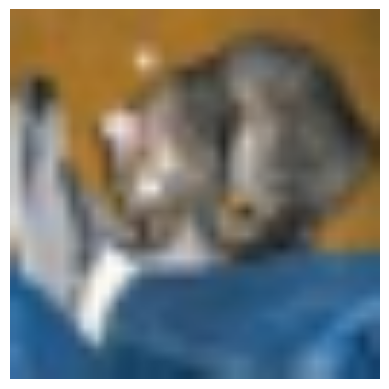

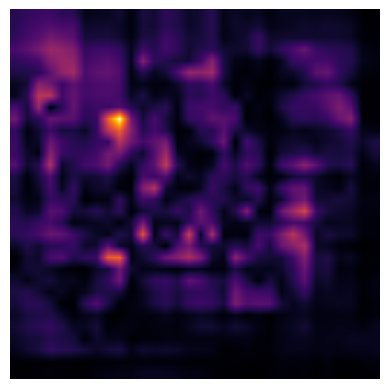

In [ ]:
'''
def prep(img_hwc_uint8):
    return to_tensor_norm(Image.fromarray(img_hwc_uint8)).unsqueeze(0).to(DEVICE)  # [1,3,32,32]

i = 0
x0 = prep(X_clean[i])
x1 = prep(X_corr[i])
y  = int(y_clean[i])


heatmap_clean = heatmap(attr_clean).cpu().squeeze().numpy()
heatmap_corr  = heatmap(attr_corr).cpu().squeeze().numpy()

fig, ax = plt.subplots(2, 2, figsize=(6,6))
ax[0,0].imshow(X_clean[i]); ax[0,0].set_title("clean"); ax[0,0].axis("off")
ax[0,1].imshow(X_corr[i]);  ax[0,1].set_title("corrupted"); ax[0,1].axis("off")
ax[1,0].imshow(hm_clean, cmap="inferno"); ax[1,0].set_title("IG heatmap clean"); ax[1,0].axis("off")
ax[1,1].imshow(hm_corr,  cmap="inferno"); ax[1,1].set_title("IG heatmap corrupted"); ax[1,1].axis("off")
plt.tight_layout()
plt.show()

img = torch.tensor(X_clean[i]).permute(2,0,1).unsqueeze(0).float() / 255.0  # [1,3,32,32]
img_up = F.interpolate(img, size=(224,224), mode="bilinear", align_corners=False)
img_up = (img_up.squeeze(0).permute(1,2,0).numpy() * 255).astype(np.uint8)

plt.imshow(img_up)
plt.axis("off")
plt.show()


hm = hm_clean  # (32,32)
hm_up = F.interpolate(torch.tensor(hm)[None,None].float(), size=(224,224), mode="bilinear", align_corners=False)
plt.imshow(hm_up.squeeze().numpy(), cmap="inferno")
plt.axis("off")
plt.show()
'''

##


In [14]:
def save_experiment_reference(
    out_dir: Path,
    seed: int,
    pair_idx,
    corruptions: list[str],
    severities: list[int],
    cifar10_mean,
    cifar10_std,
    ig_steps: int,
    internal_bs: int,
    target_policy: TargetPolicy,
    clean_ref: dict,
):
    pt_path = out_dir / "experiment_reference.pt"
    js_path  = out_dir / "experiment_reference.json"

    def cpu(x):
        return x.detach().cpu() if torch.is_tensor(x) else x

    ref_pt = {
        "seed": seed,
        "N_pairs": int(len(pair_idx)),
        "pair_idx": cpu(torch.as_tensor(pair_idx).long()),
        "corruptions": list(corruptions),
        "severities": list(severities),
        "preprocess": {
            "cifar_mean": tuple(map(float, cifar10_mean)),
            "cifar_std": tuple(map(float, cifar10_std)),
        },
        "ig_config": {
            "ig_steps": int(ig_steps),
            "internal_bs": int(internal_bs),
            "baseline": "zeros_like_input (normalized space)",
            "target_policy": target_policy.value,
        },
        "clean_reference": {
            "logits_clean": cpu(clean_ref.get("logits")),
            "pred_clean": cpu(clean_ref.get("pred")),
            "acc_clean": float(clean_ref.get("acc")),
            "entropy_clean": cpu(clean_ref.get("entropy")),
            "E_clean": cpu(clean_ref.get("E")),
            "sal_clean": to_cpu_f16(clean_ref.get("sal")),
            "sigma_ref": float(clean_ref.get("sigma")),
        },
    }

    torch.save(ref_pt, pt_path)  


    meta = {
        "seed": seed,
        "N_pairs": int(len(pair_idx)),
        "corruptions": list(corruptions),
        "severities": list(severities),
        "preprocess": ref_pt["preprocess"],
        "ig_config": ref_pt["ig_config"],
        "clean_reference_scalars": {
            "acc_clean": ref_pt["clean_reference"]["acc_clean"],
            "sigma_ref": ref_pt["clean_reference"]["sigma_ref"],
        },
        "files": {
            "reference_pt": pt_path.name,
        },
    }
    js_path.write_text(json.dumps(meta, indent=2))

In [ ]:
# or if X_clean is already your subset:
logits_clean, acc_clean = predict_logits_and_accuracy(resnet_model, clean_dataloader)
pred_clean   = transform_logits_to_preds(logits_clean)
entropy_clean = entropy_from_logits(logits_clean)   # [B]

X_clean_t = collect_x_from_loader(clean_dataloader)
E_clean = predict_resnet_embeddings(resnet_model, clean_dataloader)     
sal_clean = ig_saliency_batched(
    X_clean_t, 
    target=pred_clean, 
    device=DEVICE,
    explainer=ig, 
    steps=IG_STEPS, 
    internal_bs=BATCH_SIZE, 
    batch_size=BATCH_SIZE
) # targets: predicted class per domain (recommended for drift)

sigma_ref = estimate_sigma(E_clean)

clean_ref = {
    "logits": logits_clean,
    "pred": pred_clean,
    "acc": acc_clean,
    "entropy": entropy_clean,
    "E": E_clean,
    "sal": sal_clean,
    "sigma": sigma_ref
}

target_policy = TargetPolicy.PRED_CLEAN

data_clean = (clean_dataloader, X_clean, y_clean)

identifier = f"experiment__n{N_PAIRS}__IG_steps{IG_STEPS}__seed{SEED}"
experiments_dir = PATHS.runs / identifier
ensure_dir(experiments_dir)

save_experiment_reference(
    experiments_dir, 
    SEED, 
    pair_idx, 
    corruptions, 
    severities, 
    CIFAR10_MEAN, 
    CIFAR10_SD,
    IG_STEPS,
    BATCH_SIZE,
    target_policy,
    clean_ref
)


In [ ]:
def run_experiment_old(
        pair_idx, 
        corr_ds_path,
        data_clean, 
        corruption, 
        severity, 
        clean_ref, 
        resnet_model, 
        transform
    ):
    
    # IG explanations (timed)
    torch.cuda.synchronize() if DEVICE == "cuda" else None
    t0 = time.time()

    _, X_clean, y_clean = data_clean[0], data_clean[1], data_clean[2]

    logits_clean = clean_ref['logits']
    pred_clean = clean_ref['pred']
    E_clean = clean_ref['E']
    sal_clean = clean_ref['sal']
    sigma_ref = clean_ref['sigma']
    
    corr_dataloader, X_corr, y_corr = get_corrupted_data(
        idx=pair_idx, 
        path=corr_ds_path,
        transform=transform, 
        corruption=corruption, 
        severity=severity)


    assert X_clean.shape[0] == len(pair_idx) and X_corr.shape[0] == len(pair_idx)
    assert np.all(y_clean == y_corr)

    # predictions
    logits_corr, acc_corr = predict_logits_and_accuracy(resnet_model, corr_dataloader)
    pred_corr = transform_logits_to_preds(logits_corr)
    
    H_corr  = entropy_from_logits(logits_corr)    # [B]
    #dH = H_corr - H_clean                         # [B]
    #mean_dH = dH.mean().item()
    #mean_abs_dH = dH.abs().mean().item()

    X_corr_t = collect_x_from_loader(corr_dataloader)
    target = pred_clean if target_policy == TargetPolicy.PRED_CLEAN else pred_corr 
    sal_corr  = ig_saliency_batched(X_corr_t,  target=target, device=DEVICE, explainer=ig, steps=IG_STEPS, internal_bs=BATCH_SIZE, batch_size=BATCH_SIZE)

    # ΔE metrics
    E_corr = predict_resnet_embeddings(resnet_model, corr_dataloader)

    stable = stable_pred_mask(pred_clean, pred_corr)
    stable_rate = stable.float().mean().item()
    
    mmd2 = compute_shift_strength_mmd(E_clean, E_corr, sigma_ref)
    exp_drift_vec, exp_drift_sum = compute_explanation_drift_metrics(sal_clean, sal_corr, stable)
    conf_drift_vec, conf_drift_sum = compute_confidence_shift_metrics(logits_clean, logits_corr, stable)

    torch.cuda.synchronize() if DEVICE == "cuda" else None
    t_ig = time.time() - t0

    row = {
        "corruption": corruption, 
        "severity": severity, 
        "ig_time_sec": t_ig,
        "acc_corr": acc_corr, 
        "stable_rate": stable_rate,
        "mmd2": mmd2,
        **exp_drift_sum,  
        **conf_drift_sum    
    }

    out_dir = f"experiment__n{N_PAIRS}__IG_steps{IG_STEPS}__seed{SEED}"
    save_experiment_artifacts(corruption, severity, conf_drift_vec, exp_drift_vec, pred_corr, stable, out_dir)

    print(f"\n[{corruption} sev{severity}] IG time: {t_ig:.2f}s for N={len(pair_idx)} (steps={IG_STEPS})")

    print_results(row)

    return row

In [ ]:
def run_experiment(
        pair_idx, 
        corr_ds_path,
        data_clean, 
        corruption, 
        severity, 
        clean_ref, 
        resnet_model, 
        transform
    ):
    
    # IG explanations (timed)
    torch.cuda.synchronize() if DEVICE == "cuda" else None
    t0 = time.time()

    _, X_clean, y_clean = data_clean[0], data_clean[1], data_clean[2]
    pred_clean = clean_ref['pred']
    
    corr_dataloader, X_corr, y_corr = get_corrupted_data(
        idx=pair_idx, 
        path=corr_ds_path,
        transform=transform, 
        corruption=corruption, 
        severity=severity)


    assert X_clean.shape[0] == len(pair_idx) and X_corr.shape[0] == len(pair_idx)
    assert np.all(y_clean == y_corr)

    # predictions
    logits_corr, acc_corr = predict_logits_and_accuracy(resnet_model, corr_dataloader)
    pred_corr = transform_logits_to_preds(logits_corr)
    entropy_corr  = entropy_from_logits(logits_corr)    # [B]

    X_corr_t = collect_x_from_loader(corr_dataloader)
    target = pred_clean if target_policy == TargetPolicy.PRED_CLEAN else pred_corr 
    sal_corr  = ig_saliency_batched(X_corr_t,  target=target, device=DEVICE, explainer=ig, steps=IG_STEPS, internal_bs=BATCH_SIZE, batch_size=BATCH_SIZE)

    # ΔE metrics
    E_corr = predict_resnet_embeddings(resnet_model, corr_dataloader)

    torch.cuda.synchronize() if DEVICE == "cuda" else None
    t_ig = time.time() - t0

    row = {
        "corruption": corruption, 
        "severity": severity, 
        "time_sec": t_ig,
        "acc_corr": acc_corr,    
    }

    artifact = {
        "corruption": corruption,
        "severity": int(severity),
        "time_sec": t_ig,
        "corrupt_reference": {
            "logits_corr": logits_corr.detach().cpu(),
            "pred_corr": pred_corr.detach().cpu(),
            "acc_corr": acc_corr,    
            "entropy_corr": entropy_corr.detach().cpu(),
            "E_corr": E_corr.detach().cpu(),
            "sal_corr": to_cpu_f16(sal_corr),   
        },
    }

    out_dir = f"experiment__n{N_PAIRS}__IG_steps{IG_STEPS}__seed{SEED}"
    path = PATHS.runs / out_dir

    torch.save(artifact, f"{path}/artifacts_{corruption}_sev{severity}.pt")

    print(f"\n[{corruption} sev{severity}] IG time: {t_ig:.2f}s for N={len(pair_idx)} (steps={IG_STEPS})")
    return row

In [20]:
results = []

# ---- run per condition, time IG + compute drift ----
for corr in corruptions:
    for sev in severities:
        result = run_experiment(pair_idx, corr_ds_path, data_clean, corr, sev, clean_ref, resnet_model, to_tensor_norm)
        filename = f"experiment__n{N_PAIRS}__IG_{IG_STEPS}__{SEED}.csv"
        file_path = experiments_dir / filename
        save_results(result, file_path)
        results.append(result)
        


[gaussian_noise sev1] IG time: 15.15s for N=50 (steps=32)

[gaussian_noise sev5] IG time: 14.97s for N=50 (steps=32)
